# 实验一：A股银行股数据获取与分析（纯通达信 mootdx 数据源）

## 依赖
```
pip install pandas matplotlib mootdx
```

## 数据源策略
全部数据均通过 **mootdx**（通达信 UDP 协议）获取，稳定不封 IP：

| 数据类型 | 接口 | 说明 |
|---------|------|------|
| 股票列表 | `tdx.stocks()` | 全 A 股列表 → 按名称过滤「银行」 |
| 实时行情 | `tdx.quotes()` | 价格、涨跌幅、成交量 |
| 财务数据 | `tdx.finance()` | 每股净资产、净利润、总股本 → 计算 PE/PB/ROE |
| 历史K线 | `tdx.bars(frequency=9)` | 日线，分批拉取（单次上限 800 根 bar） |

## 功能
1. 获取 A 股银行板块全部成分股清单（含 PE、PB、ROE、总市值）
2. 获取前十大银行股自 2020 年以来的历史日线行情
3. 可视化：前十大银行股归一化走势对比 + 累计涨跌幅

## 注意事项
- mootdx 通过通达信行情服务器获取数据，无需登录
- `bars()` 单次最多返回 800 根 K 线，跨多年需分批请求
- `finance()` 返回最新一期财报数据，非历史序列

---
## 0. 环境准备

In [1]:
import os
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 通达信行情客户端
from mootdx.quotes import Quotes

# matplotlib 中文字体
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 无论从仓库根目录还是 labs/ 启动 Jupyter，都固定写入 labs/data。
WORKING_DIR = os.path.abspath("")
LABS_DIR = (
    WORKING_DIR
    if os.path.basename(WORKING_DIR) == "labs"
    else os.path.join(WORKING_DIR, "labs")
)
if not os.path.isfile(os.path.join(LABS_DIR, "pyproject.toml")):
    raise FileNotFoundError("请从仓库根目录或 labs/ 启动 Jupyter")
DATA_DIR = os.path.join(LABS_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)

# 初始化通达信客户端（std = 标准沪深市场）
tdx = Quotes.factory(market="std")

print(f"数据目录: {DATA_DIR}")
print("通达信客户端已就绪")

数据目录: D:\vibe-coding\trading-topic\labs\data
通达信客户端已就绪


---
## 工具函数：带重试的安全调用

In [2]:
def safe_call(fn, label, *args, retries=3, delay=2.0, **kwargs):
    """
    带指数退避重试的通用安全调用包装器。

    参数：
        fn:       要调用的函数
        label:    日志标签，用于打印进度
        retries:  最大重试次数（含第一次调用）
        delay:    初始等待秒数，每次重试等待时间翻倍

    返回：
        成功时返回 fn 的返回值；全部失败时返回 None
    """
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            result = fn(*args, **kwargs)
            tag = f"  [√] {label}"
            if attempt > 1:
                tag += f" (第{attempt}次)"
            print(tag)
            return result
        except Exception as e:
            last_err = e
            if attempt < retries:
                wait = delay * attempt
                print(f"  [?] {label} 重试 {attempt}/{retries}，{wait:.0f}s... ({type(e).__name__})")
                time.sleep(wait)
    print(f"  [!] {label} 失败: {type(last_err).__name__}: {last_err}")
    return None

---
## 任务 1：A 股银行板块成分股清单

**步骤：**
1. `tdx.stocks()` 获取全市场股票列表，按名称含「银行」过滤
2. `tdx.quotes()` 批量获取实时行情（价格、成交量）
3. `tdx.finance()` 逐只获取财务数据 → 计算 PE / PB / ROE / 总市值

### 1a. 获取全市场股票列表 → 过滤银行股

In [3]:
print("=" * 65)
print("  任务 1：A 股银行板块成分股清单（纯通达信数据源）")
print("=" * 65)

print("\n  → 通过通达信获取全 A 股列表，按名称过滤「银行」...")
all_stocks = tdx.stocks()

# 按名称过滤：含「银行」，且为 6 位标准 A 股代码
mask = all_stocks["name"].str.contains("银行", na=False)
mask &= all_stocks["code"].astype(str).str.match(r"^[0-3,6]\d{5}$")

bank_codes = all_stocks[mask][["code", "name"]].copy()
bank_codes["code"] = bank_codes["code"].astype(str).str.zfill(6)
bank_codes = bank_codes.drop_duplicates(subset=["code"]).reset_index(drop=True)
print(f"  [√] 筛选得到 {len(bank_codes)} 只银行股")
bank_codes.head(10)

  任务 1：A 股银行板块成分股清单（纯通达信数据源）

  → 通过通达信获取全 A 股列表，按名称过滤「银行」...


100%|##########| 28/28 [00:02<00:00, 11.37it/s]


  [√] 筛选得到 33 只银行股


,code,name
0,000134,上证银行
1,000869,HK银行  
2,600000,浦发银行
3,600015,华夏银行
4,600016,民生银行
5,600036,招商银行
6,600908,无锡银行
7,600919,江苏银行
8,600926,杭州银行
9,600928,西安银行


### 1b. 批量获取实时行情

In [4]:
print("\n  → 通过通达信批量获取实时行情...")
codes_list = bank_codes["code"].tolist()
quotes = tdx.quotes(symbol=codes_list)
print(f"  [√] 获取到 {len(quotes)} 条实时行情")

# 合并价格到银行股列表
bank_list = bank_codes.merge(
    quotes[["code", "price", "last_close", "open", "high", "low", "vol", "amount"]],
    on="code", how="left"
)
bank_list[["code", "name", "price", "vol"]].head(10)


  → 通过通达信批量获取实时行情...
  [√] 获取到 33 条实时行情


,code,name,price,vol
0,000134,上证银行,NaN,NaN
1,000869,HK银行  ,16.72,5783.0
2,600000,浦发银行,8.99,248285.0
3,600015,华夏银行,6.96,314155.0
4,600016,民生银行,3.53,1523241.0
5,600036,招商银行,38.79,344052.0
6,600908,无锡银行,5.42,97563.0
7,600919,江苏银行,11.48,490119.0
8,600926,杭州银行,15.62,104071.0
9,600928,西安银行,3.55,119485.0


### 1c. 逐只获取财务数据 → 计算 PE / PB / ROE

`tdx.finance()` 返回最新一期财报核心指标：
- `meigujingzichan` — 每股净资产 → PB
- `jinglirun` — 净利润 → PE
- `jingzichan` — 净资产 → ROE
- `zongguben` — 总股本 → 总市值

In [5]:
print(f"\n  → 通过通达信获取财务数据并计算 PE/PB/ROE（共 {len(bank_list)} 只）...")
fin_data = []

for i, (_, row) in enumerate(bank_list.iterrows()):
    code = row["code"]
    name = row["name"]
    print(f"    [{i+1:2d}/{len(bank_list)}] {name}({code}) ...", end=" ")

    fin = safe_call(tdx.finance, "", symbol=code, retries=2, delay=1)
    if fin is not None and len(fin) > 0:
        f = fin.iloc[0]
        bps    = float(f.get("meigujingzichan", np.nan))
        net_p  = float(f.get("jinglirun", np.nan))
        equity = float(f.get("jingzichan", np.nan))
        shares = float(f.get("zongguben", np.nan))

        price = row["price"]
        if pd.notna(price) and price > 0:
            mkt_cap = price * shares if pd.notna(shares) else np.nan
            pb  = price / bps if pd.notna(bps) and bps > 0 else np.nan
            pe  = mkt_cap / net_p if pd.notna(net_p) and net_p > 0 else np.nan
            roe = (net_p / equity * 100) if pd.notna(equity) and equity > 0 else np.nan
        else:
            mkt_cap = pb = pe = roe = np.nan

        fin_data.append({
            "code": code,
            "总股本": shares, "每股净资产": bps,
            "净利润": net_p, "净资产": equity,
            "总市值": mkt_cap,
            "市盈率(PE)": round(pe, 2) if pd.notna(pe) else np.nan,
            "市净率(PB)": round(pb, 2) if pd.notna(pb) else np.nan,
            "ROE(%)": round(roe, 2) if pd.notna(roe) else np.nan,
        })
        print(f"PE={pe:.1f} PB={pb:.2f} ROE={roe:.1f}%")
    else:
        fin_data.append({"code": code})
        print("跳过")
    time.sleep(0.3)

# 合并、排序
df_fin = pd.DataFrame(fin_data)
bank_list = bank_list.merge(df_fin, on="code", how="left")
bank_list = bank_list.sort_values("总市值", ascending=False, na_position="last").reset_index(drop=True)
bank_list.insert(0, "序号", range(1, len(bank_list) + 1))

# 打印
cols_show = ["序号", "code", "name", "price", "市盈率(PE)", "市净率(PB)", "ROE(%)", "总市值"]
print(f"\n  【银行板块共 {len(bank_list)} 只，按总市值排序】")
print(bank_list[cols_show].to_string(index=False,
    float_format=lambda x: f"{x:.2f}" if pd.notna(x) else "N/A",
    formatters={"code": lambda x: str(x).zfill(6), "总市值": lambda x: f"{x:.0f}"}))


  → 通过通达信获取财务数据并计算 PE/PB/ROE（共 33 只）...
    [ 1/33] 上证银行(000134) ...   [√] 
PE=nan PB=nan ROE=nan%
    [ 2/33] HK银行  (000869) ...   [√] 
PE=7.4 PB=1.05 ROE=1.4%
    [ 3/33] 浦发银行(600000) ...   [√] 
PE=1.7 PB=0.40 ROE=2.1%
    [ 4/33] 华夏银行(600015) ...   [√] 
PE=2.2 PB=0.34 ROE=1.2%
    [ 5/33] 民生银行(600016) ...   [√] 
PE=1.3 PB=0.27 ROE=1.6%
    [ 6/33] 招商银行(600036) ...   [√] 
PE=2.6 PB=0.86 ROE=3.0%
    [ 7/33] 无锡银行(600908) ...   [√] 
PE=1.9 PB=0.51 ROE=2.7%
    [ 8/33] 江苏银行(600919) ...   [√] 
PE=2.0 PB=0.80 ROE=3.1%
    [ 9/33] 杭州银行(600926) ...   [√] 
PE=1.7 PB=0.81 ROE=3.9%
    [10/33] 西安银行(600928) ...   [√] 
PE=2.1 PB=0.44 ROE=1.8%
    [11/33] 南京银行(601009) ...   [√] 
PE=2.1 PB=0.74 ROE=3.1%
    [12/33] 常熟银行(601128) ...   [√] 
PE=1.9 PB=0.71 ROE=3.7%
    [13/33] 兴业银行(601166) ...   [√] 
PE=1.6 PB=0.46 ROE=2.6%
    [14/33] 北京银行(601169) ...   [√] 
PE=1.3 PB=0.38 ROE=2.1%
    [15/33] 厦门银行(601187) ...   [√] 
PE=2.9 PB=0.73 ROE=2.1%
    [16/33] 上海银行(601229) ...   [√] 
PE=2.0 PB=0.51 ROE=2.4

In [6]:
# 保存清单
list_path = os.path.join(DATA_DIR, "银行股清单.csv")
bank_list.to_csv(list_path, index=False, encoding="utf-8-sig")
print(f"\n  → 清单已保存: labs/data/银行股清单.csv")


  → 清单已保存: labs/data/银行股清单.csv


---
## 任务 2：前十大银行股历史日线（2020 年至今）

使用 `tdx.bars(frequency=9)` 获取日线 K 线：
- `frequency=9` 日线，`frequency=5` 周线，`frequency=8` 月线
- 单次最多 800 根 bar，分两批拉取覆盖 ~6 年

In [7]:
print("\n" + "=" * 65)
print("  任务 2：前十大银行股历史日线 (2020-01-01 → 最新)")
print("=" * 65)

top10 = bank_list.head(10)
hist_data = {}  # code → {name, df, date_col, close_col}

for _, row in top10.iterrows():
    code = str(row["code"]).zfill(6)
    name = str(row["name"])
    seq = row["序号"]
    print(f"\n  [{seq:2d}] {name}({code}) ", end="")

    # 分批拉取：先取最近 800 根，再取更早的 800 根
    frames = []
    for batch_start in [0, 800]:
        time.sleep(0.3)
        bars = safe_call(
            tdx.bars, f"{name} 第{batch_start // 800 + 1}批",
            symbol=code, frequency=9, start=batch_start, offset=800,
            retries=2, delay=1,
        )
        if bars is not None and len(bars) > 0:
            frames.append(bars)
        else:
            break

    if not frames:
        print("  → 跳过（无数据）")
        continue

    df_hist = pd.concat(frames, axis=0)
    df_hist = df_hist[~df_hist.index.duplicated(keep="first")]
    df_hist = df_hist.sort_index()
    df_hist = df_hist[df_hist.index >= "2020-01-01"]

    df_hist = df_hist.rename(columns={
        "open": "开盘", "close": "收盘", "high": "最高",
        "low": "最低", "vol": "成交量", "amount": "成交额",
    })
    df_hist["日期"] = df_hist.index
    df_hist = df_hist.sort_values("日期").reset_index(drop=True)

    csv_path = os.path.join(DATA_DIR, f"{name}_{code}.csv")
    df_hist.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"→ {len(df_hist)} 行 → labs/data/{name}_{code}.csv")

    hist_data[code] = {"name": name, "df": df_hist, "date_col": "日期", "close_col": "收盘"}

print(f"\n  → 共获取 {len(hist_data)} / {len(top10)} 只股票历史数据")


  任务 2：前十大银行股历史日线 (2020-01-01 → 最新)

  [ 1] 工商银行(601398)   [√] 工商银行 第1批
  [√] 工商银行 第2批
→ 1588 行 → labs/data/工商银行_601398.csv

  [ 2] 建设银行(601939)   [√] 建设银行 第1批
  [√] 建设银行 第2批
→ 1588 行 → labs/data/建设银行_601939.csv

  [ 3] 农业银行(601288)   [√] 农业银行 第1批
  [√] 农业银行 第2批
→ 1588 行 → labs/data/农业银行_601288.csv

  [ 4] 中国银行(601988)   [√] 中国银行 第1批
  [√] 中国银行 第2批
→ 1588 行 → labs/data/中国银行_601988.csv

  [ 5] 招商银行(600036)   [√] 招商银行 第1批
  [√] 招商银行 第2批
→ 1588 行 → labs/data/招商银行_600036.csv

  [ 6] 交通银行(601328)   [√] 交通银行 第1批
  [√] 交通银行 第2批
→ 1588 行 → labs/data/交通银行_601328.csv

  [ 7] 邮储银行(601658)   [√] 邮储银行 第1批
  [√] 邮储银行 第2批
→ 1588 行 → labs/data/邮储银行_601658.csv

  [ 8] 中信银行(601998)   [√] 中信银行 第1批
  [√] 中信银行 第2批
→ 1588 行 → labs/data/中信银行_601998.csv

  [ 9] 兴业银行(601166)   [√] 兴业银行 第1批
  [√] 兴业银行 第2批
→ 1588 行 → labs/data/兴业银行_601166.csv

  [10] 浦发银行(600000)   [√] 浦发银行 第1批
  [√] 浦发银行 第2批
→ 1588 行 → labs/data/浦发银行_600000.csv

  → 共获取 10 / 10 只股票历史数据


---
## 任务 3：可视化 — 归一化走势 + 累计涨跌幅

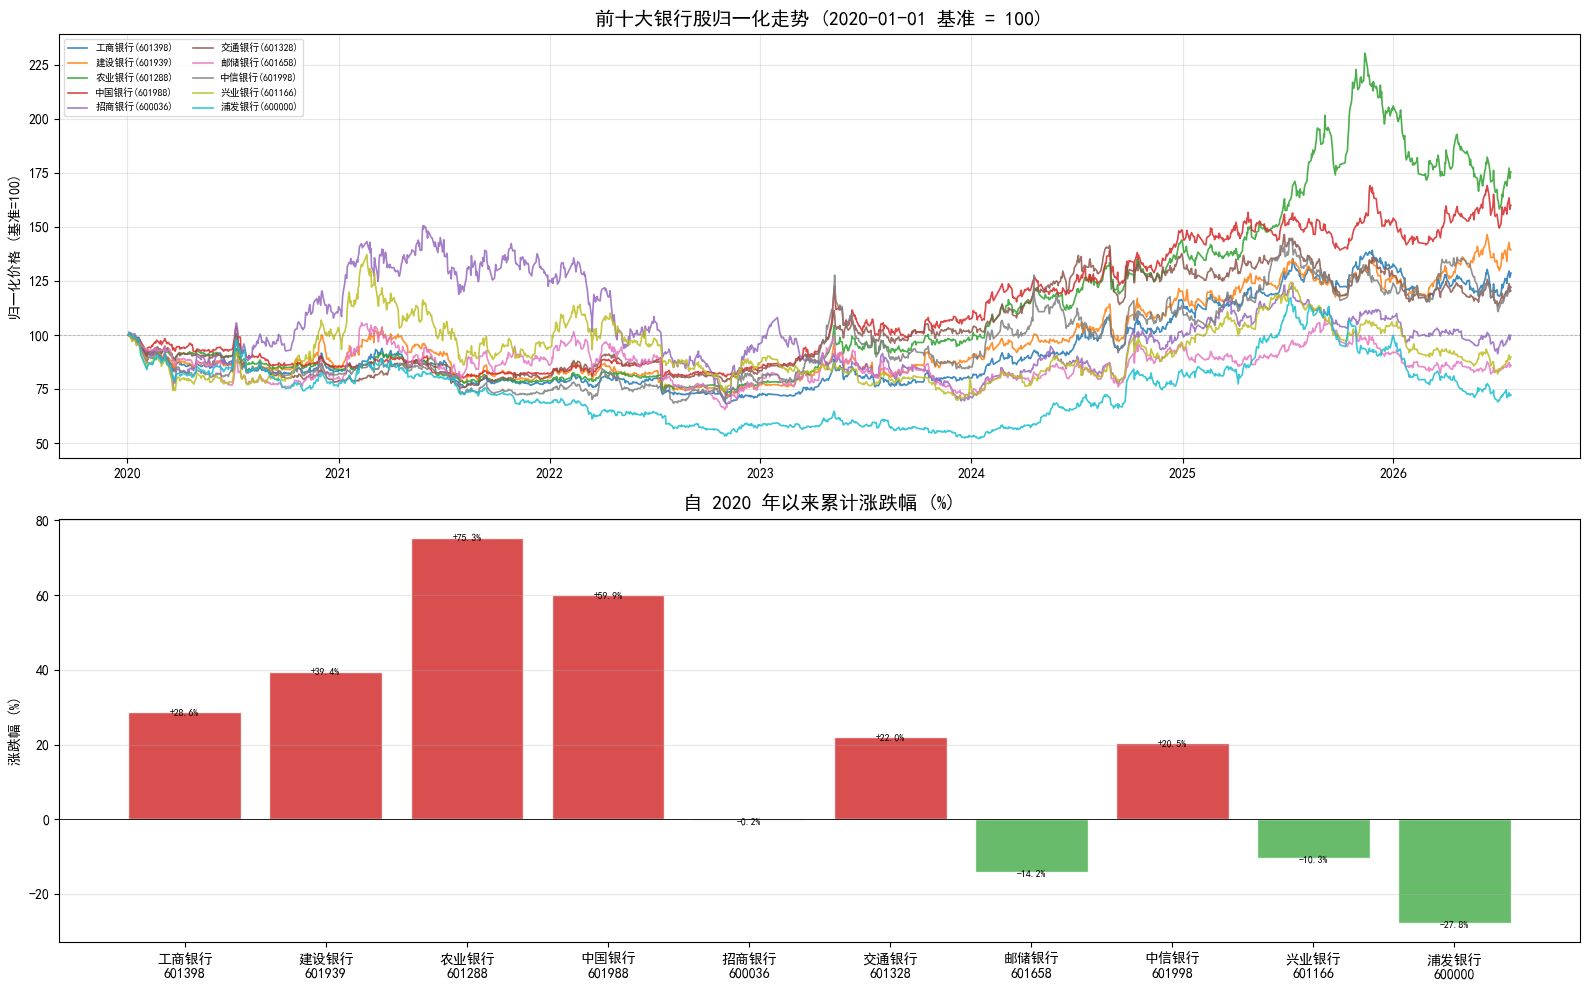


  → 图表已保存


In [8]:
if len(hist_data) >= 2:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    colors = plt.cm.tab10(range(len(hist_data)))

    # ── 图 1：归一化走势 (2020-01-01 基准 = 100) ──
    ax1 = axes[0]
    for idx, (code, info) in enumerate(hist_data.items()):
        df = info["df"]
        close_vals = df[info["close_col"]].values
        norm = close_vals / close_vals[0] * 100
        ax1.plot(df[info["date_col"]], norm, color=colors[idx],
                 linewidth=1.2, label=f"{info['name']}({code})", alpha=0.85)

    ax1.axhline(y=100, color="gray", linestyle="--", linewidth=0.6, alpha=0.5)
    ax1.set_title("前十大银行股归一化走势 (2020-01-01 基准 = 100)", fontsize=14, fontweight="bold")
    ax1.set_ylabel("归一化价格 (基准=100)")
    ax1.legend(loc="upper left", fontsize=7, ncol=2, framealpha=0.7)
    ax1.grid(True, alpha=0.3)

    # ── 图 2：累计涨跌幅柱状图 ──
    ax2 = axes[1]
    names_list, returns_list, bar_colors = [], [], []
    for code, info in hist_data.items():
        close_vals = info["df"][info["close_col"]].values
        ret = (close_vals[-1] / close_vals[0] - 1) * 100
        names_list.append(f"{info['name']}\n{code}")
        returns_list.append(ret)
        bar_colors.append("#d32f2f" if ret >= 0 else "#4caf50")

    bars = ax2.bar(names_list, returns_list, color=bar_colors, alpha=0.85, edgecolor="white")
    ax2.set_title("自 2020 年以来累计涨跌幅 (%)", fontsize=14, fontweight="bold")
    ax2.set_ylabel("涨跌幅 (%)")
    ax2.axhline(y=0, color="black", linewidth=0.6)
    ax2.grid(True, alpha=0.3, axis="y")

    for bar, ret in zip(bars, returns_list):
        y_pos = bar.get_height() + (1 if ret >= 0 else -1.5)
        ax2.text(bar.get_x() + bar.get_width() / 2, y_pos,
                 f"{ret:+.1f}%", ha="center", va="top" if ret >= 0 else "bottom",
                 fontsize=7, fontweight="bold")

    plt.tight_layout()
    chart_path = os.path.join(DATA_DIR, "lab1_bank_top10_chart.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  → 图表已保存")
else:
    print("  历史数据不足 (少于 2 只)，跳过绘图。")

---
## 输出汇总

In [9]:
print(f"\n{'=' * 65}")
print(f"  实验一完成！（纯通达信 mootdx 数据源）")
print(f"  - 银行股清单: labs/data/银行股清单.csv ({len(bank_list)} 只)")
print(f"  - 历史行情文件 ({len(hist_data)} 只):")
for code, info in hist_data.items():
    print(f"    labs/data/{info['name']}_{code}.csv")
print(f"{'=' * 65}")


  实验一完成！（纯通达信 mootdx 数据源）
  - 银行股清单: labs/data/银行股清单.csv (33 只)
  - 历史行情文件 (10 只):
    labs/data/工商银行_601398.csv
    labs/data/建设银行_601939.csv
    labs/data/农业银行_601288.csv
    labs/data/中国银行_601988.csv
    labs/data/招商银行_600036.csv
    labs/data/交通银行_601328.csv
    labs/data/邮储银行_601658.csv
    labs/data/中信银行_601998.csv
    labs/data/兴业银行_601166.csv
    labs/data/浦发银行_600000.csv
